# CV5570 - Computer Vision for Construction Engineering Asssignment 1
## Image-Based Change Detection and Feature Matching

This Notebook presentws the experimental analysis of the classical computer vision and deep learning approaches for image-based change detection and feature Matching. And also for experimenting image stiching pipeline

### Import the Necessary packages

In [32]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import sys
import os
from pathlib import Path
import subprocess

### Dataset and Image Analysis

In [2]:
img1 = cv2.imread('./images/image1.jpg')
img2 = cv2.imread('./images/image2.jpg')
img3 = cv2.imread('./images/image3.jpg')

In [3]:
for i, img in enumerate([img1, img2, img3], 1):
    print(f"Image {i}:")
    print(f"  Shape: {img.shape}")
    print(f"  Data type: {img.dtype}")

Image 1:
  Shape: (2252, 4000, 3)
  Data type: uint8
Image 2:
  Shape: (2252, 4000, 3)
  Data type: uint8
Image 3:
  Shape: (2252, 4000, 3)
  Data type: uint8


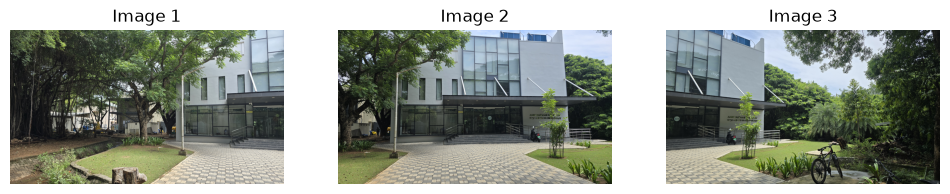

In [4]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Image 1")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Image 2")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Image 3")

plt.show()

### 2. Classical Feature Matching Methods Comparison 

SIFT, SURF **(not possible to implement SURF since it is a patented algorithm)** and ORB are evaluated on the given images to select a suitable classical feature-matching method. The comparison considers feature detection, descriptor characteristics, matching performance, computational cost, and robustness.

In [5]:
def extract_features(detector, images):
    
    feature_data = {}

    for image_name, image in images.items():

        start_time = time.perf_counter()

        keypoints, descriptors = detector.detectAndCompute(
            image,
            None
        )

        elapsed_time = time.perf_counter() - start_time

        feature_data[image_name] = {
            "keypoints": keypoints,
            "descriptors": descriptors,
            "time": elapsed_time
        }

    return feature_data

In [6]:
def match_features(descriptor1, descriptor2, norm_type, ratio_threshold=0.75):

    matcher = cv2.BFMatcher(
        norm_type,
        crossCheck=False
    )

    start_time = time.perf_counter()

    knn_matches = matcher.knnMatch(
        descriptor1,
        descriptor2,
        k=2
    )

    matching_time = time.perf_counter() - start_time

    good_matches = []

    for pair in knn_matches:

        if len(pair) < 2:
            continue

        m, n = pair

        if m.distance < ratio_threshold * n.distance:
            good_matches.append(m)

    return good_matches, matching_time

In [7]:
images = {
    "Image 1": img1,
    "Image 2": img2,
    "Image 3": img3,
}
gray_images = {
    name: cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    for name, image in images.items()
}

##### SIFT (Scale-Invariant Feature Transform)

SIFT detects local features across different scales and describes them using gradient-based descriptors. It is designed to provide robustness to scale and rotation changes.

In [8]:
sift = cv2.SIFT_create(nfeatures=5000)

print("SIFT detector created successfully")

SIFT detector created successfully


In [9]:
sift_features = extract_features(sift, gray_images)

In [10]:
# Inspecting the SIFT results

sift_summary = pd.DataFrame([
    {
        "Image": name,
        "Keypoints": len(data["keypoints"]),
        "Descriptor shape": data["descriptors"].shape,
        "Time (s)": data["time"]
    }
    for name, data in sift_features.items()
])

sift_summary

,Image,Keypoints,Descriptor shape,Time (s)
0,Image 1,5000,"(5000, 128)",2.282643
1,Image 2,5000,"(5000, 128)",1.690378
2,Image 3,5001,"(5001, 128)",1.717508


##### ORB

ORB combines FAST keypoint detection with an oriented binary descriptor based on BRIEF. It is designed for computationally efficient feature detection and matching.

In [11]:
orb = cv2.ORB_create(nfeatures=5000)

print("ORB detector created successfully")

ORB detector created successfully


In [12]:
orb_features = extract_features(orb, gray_images)

In [13]:
# Inspecting the ORB results

orb_summary = pd.DataFrame([
    {
        "Image": name,
        "Keypoints": len(data["keypoints"]),
        "Descriptor shape": data["descriptors"].shape,
        "Time (s)": data["time"]
    }
    for name, data in orb_features.items()
])

orb_summary

,Image,Keypoints,Descriptor shape,Time (s)
0,Image 1,5000,"(5000, 32)",0.487610
1,Image 2,5000,"(5000, 32)",0.187992
2,Image 3,5000,"(5000, 32)",0.195889


##### SURF

SURF detects features using a Hessian-based scale-space approach and describes them using Haar wavelet responses. **SURF is not implemented since it is a patented algorithm and it is unusable with opencv 5.x version.**

#### Experimental Comparison

In [14]:
detection_comparison = pd.DataFrame([
    {
        "Image": name,
        "SIFT Keypoints": len(sift_features[name]["keypoints"]),
        "ORB Keypoints": len(orb_features[name]["keypoints"]),
        "SIFT Time (s)": sift_features[name]["time"],
        "ORB Time (s)": orb_features[name]["time"]
    }
    for name in gray_images
])

detection_comparison

,Image,SIFT Keypoints,ORB Keypoints,SIFT Time (s),ORB Time (s)
0,Image 1,5000,5000,2.282643,0.487610
1,Image 2,5000,5000,1.690378,0.187992
2,Image 3,5001,5000,1.717508,0.195889


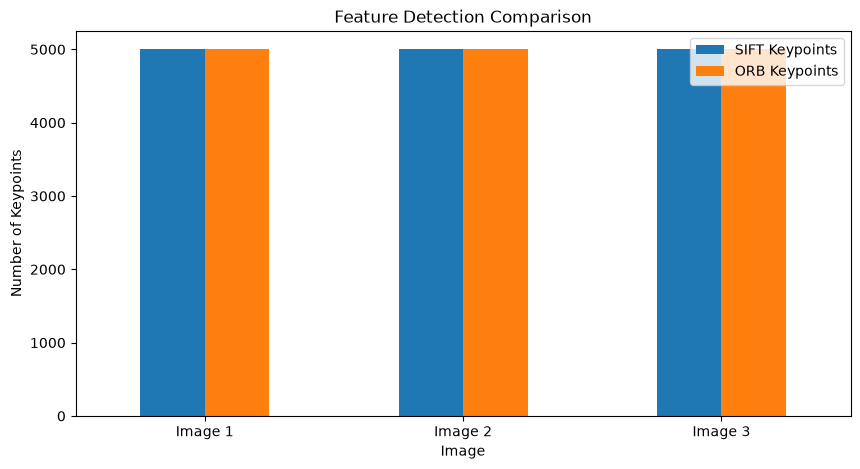

In [15]:
detection_comparison.plot(
    x="Image",
    y=["SIFT Keypoints", "ORB Keypoints"],
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Number of Keypoints")
plt.title("Feature Detection Comparison")
plt.xticks(rotation=0)
plt.show()

#### Feature Matching

Brute-force KNN matching with Lowe's ratio test is used to identify reliable feature correspondences between image pairs.

In [16]:
image_pairs = [
    ("Image 1", "Image 2"),
    ("Image 1", "Image 3"),
    ("Image 2", "Image 3")
]

##### SIFT Matching

In [17]:
sift_matches = {}

for image1, image2 in image_pairs:

    matches, matching_time = match_features(
        sift_features[image1]["descriptors"],
        sift_features[image2]["descriptors"],
        cv2.NORM_L2
    )

    sift_matches[(image1, image2)] = {
        "matches": matches,
        "time": matching_time
    }

##### ORB Matching

In [18]:
orb_matches = {}

for image1, image2 in image_pairs:

    matches, matching_time = match_features(
        orb_features[image1]["descriptors"],
        orb_features[image2]["descriptors"],
        cv2.NORM_HAMMING
    )

    orb_matches[(image1, image2)] = {
        "matches": matches,
        "time": matching_time
    }

##### Matching Comparison

In [19]:
matching_comparison = pd.DataFrame([
    {
        "Image Pair": f"{image1} - {image2}",
        "SIFT Matches": len(sift_matches[(image1, image2)]["matches"]),
        "ORB Matches": len(orb_matches[(image1, image2)]["matches"]),
        "SIFT Matching Time (s)": sift_matches[(image1, image2)]["time"],
        "ORB Matching Time (s)": orb_matches[(image1, image2)]["time"]
    }
    for image1, image2 in image_pairs
])

matching_comparison

,Image Pair,SIFT Matches,ORB Matches,SIFT Matching Time (s),ORB Matching Time (s)
0,Image 1 - Image 2,75,105,0.280239,0.160178
1,Image 1 - Image 3,18,15,0.253282,0.146443
2,Image 2 - Image 3,56,58,0.248244,0.145282


##### Representative Matches

In [20]:
def draw_bold_matches(
    image1,
    image2,
    keypoints1,
    keypoints2,
    matches,
    max_matches=50,
    thickness=3
):
    matches = matches[:max_matches]

    h1, w1 = image1.shape[:2]
    h2, w2 = image2.shape[:2]

    canvas = np.zeros(
        (max(h1, h2), w1 + w2, 3),
        dtype=np.uint8
    )

    canvas[:h1, :w1] = image1
    canvas[:h2, w1:w1 + w2] = image2

    rng = np.random.default_rng(42)

    for match in matches:

        pt1 = tuple(
            np.round(keypoints1[match.queryIdx].pt).astype(int)
        )

        pt2 = tuple(
            np.round(keypoints2[match.trainIdx].pt).astype(int)
        )

        pt2 = (pt2[0] + w1, pt2[1])

        color = tuple(
            int(x) for x in rng.integers(50, 256, 3)
        )

        cv2.line(
            canvas,
            pt1,
            pt2,
            color,
            thickness,
            cv2.LINE_AA
        )

        cv2.circle(
            canvas,
            pt1,
            5,
            (0, 255, 0),
            2
        )

        cv2.circle(
            canvas,
            pt2,
            5,
            (0, 255, 0),
            2
        )

    return canvas

##### SIFT

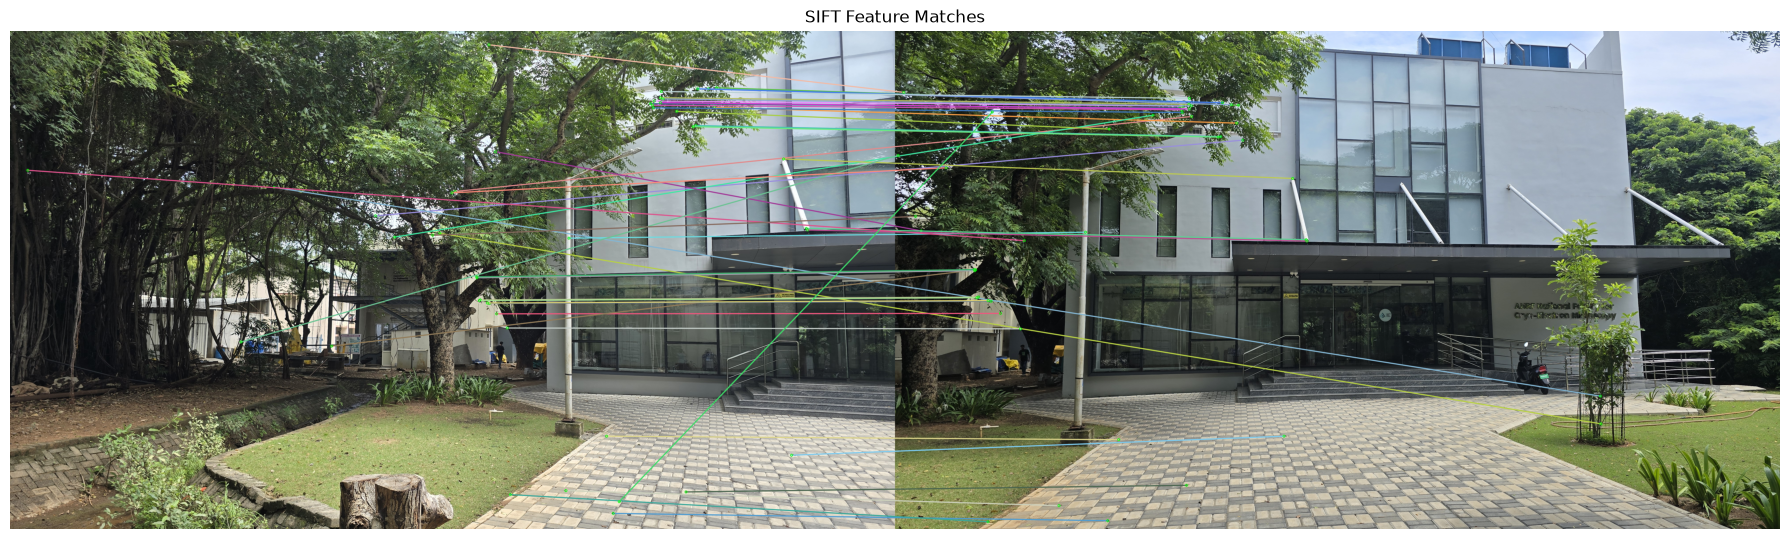

In [21]:
pair = ("Image 1", "Image 2")

match_image = draw_bold_matches(
    images[pair[0]],
    images[pair[1]],
    sift_features[pair[0]]["keypoints"],
    sift_features[pair[1]]["keypoints"],
    sift_matches[pair]["matches"],
    max_matches=50,
    thickness=3
)

plt.figure(figsize=(18, 9))
plt.imshow(cv2.cvtColor(match_image, cv2.COLOR_BGR2RGB))
plt.title("SIFT Feature Matches")
plt.axis("off")
plt.tight_layout()
plt.show()

##### ORB

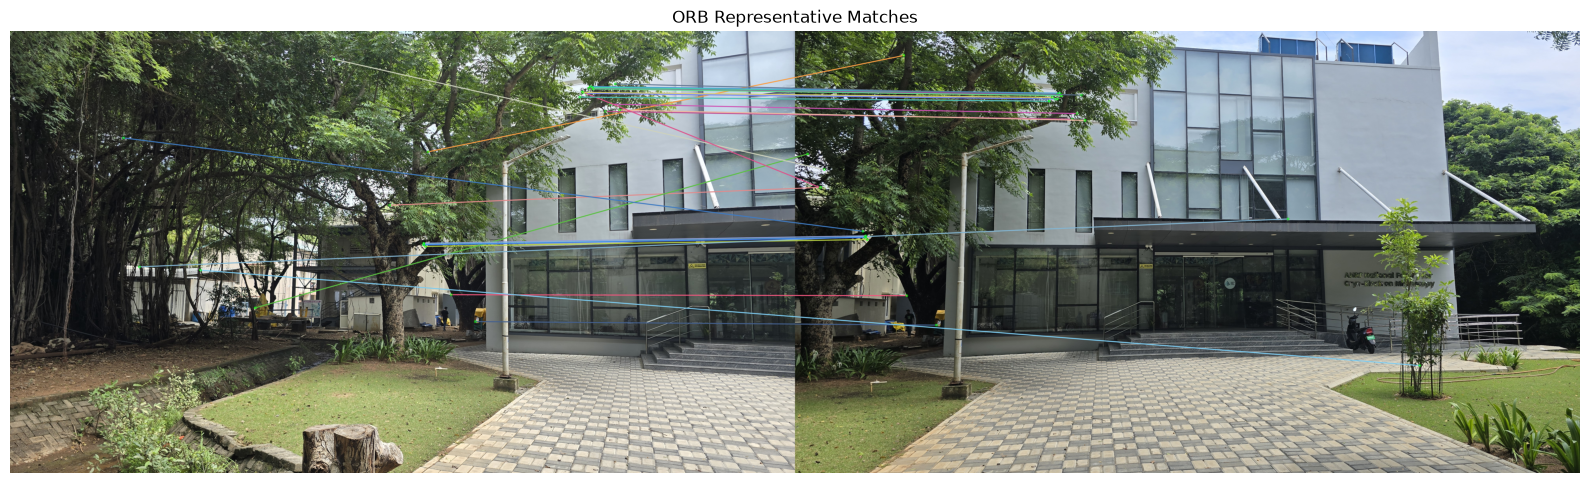

In [22]:
pair = ("Image 1", "Image 2")

match_image = draw_bold_matches(
    images[pair[0]],
    images[pair[1]],
    orb_features[pair[0]]["keypoints"],
    orb_features[pair[1]]["keypoints"],
    orb_matches[pair]["matches"],
    max_matches=30,
    thickness=3
)

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(match_image, cv2.COLOR_BGR2RGB))
plt.title("ORB Representative Matches")
plt.axis("off")
plt.tight_layout()
plt.show()

#### SIFT, ORB, and SURF Comparison

SIFT, ORB, and SURF differ in their feature detection strategy, descriptor representation, invariance, computational complexity, and typical applications.

In [23]:
method_comparison = pd.DataFrame([
    {
        "Property": "Detector",
        "SIFT": "Difference of Gaussian (DoG)",
        "ORB": "FAST",
        "SURF": "Hessian matrix approximation"
    },
    {
        "Property": "Descriptor",
        "SIFT": "Gradient histogram",
        "ORB": "Oriented BRIEF",
        "SURF": "Haar wavelet responses"
    },
    {
        "Property": "Descriptor Type",
        "SIFT": "Floating-point",
        "ORB": "Binary",
        "SURF": "Floating-point"
    },
    {
        "Property": "Rotation Invariance",
        "SIFT": "Yes",
        "ORB": "Yes",
        "SURF": "Yes"
    },
    {
        "Property": "Scale Invariance",
        "SIFT": "Yes",
        "ORB": "Limited",
        "SURF": "Yes"
    },
    {
        "Property": "Matching Distance",
        "SIFT": "Euclidean (L2)",
        "ORB": "Hamming",
        "SURF": "Euclidean (L2)"
    },
    {
        "Property": "Computational Complexity",
        "SIFT": "High",
        "ORB": "Low",
        "SURF": "Medium"
    },
    {
        "Property": "Robustness",
        "SIFT": "High",
        "ORB": "Moderate",
        "SURF": "High"
    },
    {
        "Property": "Typical Applications",
        "SIFT": "Image matching and registration",
        "ORB": "Real-time vision and SLAM",
        "SURF": "Image matching and recognition"
    }
])

method_comparison

,Property,SIFT,ORB,SURF
0,Detector,Difference of Gaussian (DoG),FAST,Hessian matrix approximation
1,Descriptor,Gradient histogram,Oriented BRIEF,Haar wavelet responses
2,Descriptor Type,Floating-point,Binary,Floating-point
3,Rotation Invariance,Yes,Yes,Yes
4,Scale Invariance,Yes,Limited,Yes
5,Matching Distance,Euclidean (L2),Hamming,Euclidean (L2)
6,Computational Complexity,High,Low,Medium
7,Robustness,High,Moderate,High
8,Typical Applications,Image matching and registration,Real-time vision and SLAM,Image matching and recognition


##### Selection of the Classical Method

Based on the experimental results, the classical feature-matching method is selected by considering the number of reliable matches, detection and matching time, descriptor characteristics, and the visual quality of the correspondences. The selected method will be used for the subsequent implementation.

##### Selected Method: **ORB**

ORB was selected as the classical feature-matching method based on the experimental comparison with SIFT. Both methods were evaluated using approximately 5000 detected features per image to provide a controlled comparison.

ORB produced a higher average number of good matches across the three image pairs (59.3) compared with SIFT (49.7). In addition, ORB required substantially less feature detection time, with an average of approximately 0.20 s per image compared with 2.05 s for SIFT. ORB also achieved lower average matching time.

Although SIFT produced slightly more matches for the Image 1–Image 3 pair, ORB provided better overall matching performance with significantly lower computational cost. Therefore, ORB was selected for the subsequent classical feature detection, description, and matching implementation.

### 3. Deep Learning based Feature Matching

For the deep-learning based feature matching experiment, the **R2D2 (Repeatable and Reliable Detector and Descriptor)** method is used.

R2D2 was proposed by Revaud et al. at NeurIPS 2019. Unlike classical feature methods such as SIFT and ORB, R2D2 uses a convolutional neural network to jointly learn local feature detection and description.

#### R2D2 Implementation

The official R2D2 implementation is based on PyTorch and provides pre-trained models for feature extraction.

The pretrained `r2d2_WASF_N16.pt` model is used in this experiment. The model produces approximately 5000 keypoints, which also provides a reasonable comparison with the controlled SIFT and ORB experiments, where 5000 features were used.

In [25]:
print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("OpenCV:", cv2.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
PyTorch: 2.13.0+cpu
OpenCV: 5.0.0
Device: cpu


#### Hardware

R2D2 inference can be performed using either CPU or GPU. A CUDA-enabled GPU is preferred because neural-network inference is computationally more expensive than classical feature extraction.

The experiment therefore uses the available CUDA device when detected; otherwise, inference is performed on the CPU.

In [ ]:
model_path = "./r2d2/models/r2d2_WASF_N16.pt"

print("Model exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("Model size:", round(os.path.getsize(model_path) / (1024 ** 2), 2),"MB")

Model exists: True
Model size: 1.86 MB


#### R2D2 Core Idea

R2D2 is a learned local feature detector and descriptor.

The method is based on the observation that a visually salient point is not necessarily a good point for image matching. A region may have strong visual structure but still be ambiguous when compared with another image.

R2D2 therefore predicts three related quantities:
1. A local feature descriptor.
2. A repeatability score indicating whether the feature can be detected consistently under image changes.
1. A reliability score indicating whether the descriptor is sufficiently discriminative for matching.

The detector therefore favors points that are both repeatable and reliable rather than selecting points solely because they are visually salient.

The descriptors produced by the network are then matched between images using descriptor similarity.

#### Difference from Classical Feature Matching

The classical methods used previously rely on handcrafted image
processing operations.

- **SIFT** detects scale-space extrema and constructs handcrafted gradient-based descriptors.
- **ORB** uses FAST-based keypoint detection and a binary descriptor derived from BRIEF.
- **SURF** uses handcrafted approximations of scale-space filtering and Haar-wavelet based descriptors.
- **R2D2** learns feature representations using a convolutional neural network trained with metric-learning based objectives.

Therefore, the main difference is that SIFT, ORB and SURF define the feature representation explicitly, whereas R2D2 learns the feature representation from training data.

R2D2 also introduces a reliability prediction, allowing ambiguous regions to be rejected before matching.

### Loading the Pretrained Network

The pretrained weights released by the authors are used rather than training R2D2 from scratch. This is necessary because training the network requires the original training data and training procedure, which is beyond the scope of this assignment. The official extraction script is used to generate the keypoints, descriptors and scores for each image.

In [37]:
r2d2_dir = Path("./r2d2")
model_path = "models/r2d2_WASF_N16.pt"

image_paths = [
    "../images/image1.jpg",
    "../images/image2.jpg",
    "../images/image3.jpg"
]

command = [
    sys.executable,
    "extract.py",
    "--model", model_path,
    "--images", *image_paths,
    "--top-k", "5000"
]

result = subprocess.run(
    command,
    cwd=r2d2_dir,
    capture_output=True,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    print(result.stderr)


Traceback (most recent call last):
  File "e:\CV5570\CV5570_Assignment_1\r2d2\extract.py", line 182, in <module>
    extract_keypoints(args)
    ~~~~~~~~~~~~~~~~~^^^^^^
  File "e:\CV5570\CV5570_Assignment_1\r2d2\extract.py", line 112, in extract_keypoints
    iscuda = common.torch_set_gpu(args.gpu)
  File "e:\CV5570\CV5570_Assignment_1\r2d2\tools\common.py", line 32, in torch_set_gpu
    os.environ['HOSTNAME'],os.environ['CUDA_VISIBLE_DEVICES'])
    ~~~~~~~~~~^^^^^^^^^^^^
  File "<frozen os>", line 717, in __getitem__
KeyError: 'HOSTNAME'



In [29]:
r2d2_features = {}

for image_name, image_path in zip(image_names, image_paths):

    feature_file = image_path + ".r2d2"

    data = np.load(feature_file)

    r2d2_features[image_name] = {
        "keypoints": data["keypoints"],
        "descriptors": data["descriptors"],
        "scores": data["scores"]
    }

    print(
        image_name,
        "Keypoints:", len(data["keypoints"]),
        "Descriptor shape:", data["descriptors"].shape
    )

FileNotFoundError: [Errno 2] No such file or directory: './images/image1.jpg.r2d2'